# 07 — RoomBeacon Performance Benchmark

This notebook establishes the empirical runtime and system performance baseline for the frozen **LightGBM Regressor / RAW / F4** RoomBeacon champion.

It answers: **"How efficiently does the frozen RoomBeacon champion run?"**

It strictly measures:
- Artifact loading cost (cold vs warm)
- Preprocessing and feature preparation overhead
- Single-row request latency vs batch throughput
- Latency distributions (P50, P90, P95, P99)
- Memory usage (RSS via `psutil`) and stability across repeated cycles
- Scaling behavior across workload sizes (1 to ~129k full population)
- Detailed 7-stage pipeline breakdown
- Valid edge-case input robustness
- Multi-threaded batch concurrency

This notebook **never trains, tunes, fits, compares model families, or modifies data**. It is a **measure-first** engineering benchmark.

## 01. Purpose and Frozen Champion Contract

### Architectural Ownership
- **Notebook 04 (Modeling)**: Selects, tunes, and freezes the immutable champion package (`champion_model.joblib`, `champion_metadata.json`).
- **Notebook 06 (Shadow Validation)**: Evaluates predictive accuracy, residuals, and distribution drift against historical and future data.
- **Notebook 07 (Performance Benchmark)**: Measures operational latency, throughput, memory, and CPU utilization under realistic runtime workloads.

```
04 Modeling (Locked Champion Artifact)
       │
       ├──────────────► 06 Shadow Validation (Model Quality & Drift)
       │
       └──────────────► 07 Performance Benchmark (Runtime & System Efficiency)
```

### Frozen Champion Contract
- Model Family: `LightGBM Regressor`
- Target Transform: `RAW`
- Feature Set: `F4 — AREA + SOURCE + LOCATION` (4 features: `area_value_clean`, `source_code`, `ward_current`, `district_text_extracted`)
- Model ID: `roombeacon-price-lgbm-f4-raw-0b0c9d9fa450`
- Target-Free Inference: Prediction relies strictly on F4 features; actual monthly rent is never required or exposed to the model.
- Performance SLA: No arbitrary pass/fail thresholds are assumed. The goal is to **measure and establish an empirical baseline**.

## 02. Benchmark Environment

In [19]:
from pathlib import Path
from datetime import datetime, timezone
import json, platform, sys, os, psutil

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'crawler').is_dir() and (p / 'analytics').is_dir())
sys.path.insert(0, str(PROJECT_ROOT))

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.shadow_validation import resolve_champion_artifact, prepare_shadow_population, file_sha256
from notebooks.utils.performance_benchmark import (
    BENCHMARK_RANDOM_SEED,
    PERF_BENCHMARK_DIR_NAME,
    get_benchmark_environment,
    get_process_memory_mb,
    compute_latency_statistics,
    compute_throughput,
    sample_workload,
    hash_workload_ids,
    run_base_benchmark,
    run_standard_benchmark,
    run_cold_vs_warm_benchmark,
    run_pipeline_stage_breakdown,
    run_scaling_benchmark,
    run_repeated_stability_benchmark,
    run_memory_stability_check,
    run_robustness_benchmark,
    run_concurrency_benchmark,
    get_champion_quality_context,
    make_performance_run_id,
    persist_performance_run,
    build_performance_scorecard,
)

np.random.seed(BENCHMARK_RANDOM_SEED)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

BENCHMARK_DIR = PROJECT_ROOT / 'data' / 'modeling' / 'roombeacon_price_benchmark_v3'
SILVER_PATH = resolve_runtime_path(env.processing.silver_dir) / 'rental_listings.parquet'
PERF_OUTPUT_ROOT = PROJECT_ROOT / 'data' / 'modeling' / PERF_BENCHMARK_DIR_NAME

env_info = get_benchmark_environment()
env_display = pd.Series({
    'OS': f"{env_info['os']} ({env_info['os_release']})",
    'Architecture': env_info['architecture'],
    'Processor': env_info['processor'],
    'Logical Cores': env_info['logical_cpus'],
    'Physical Cores': env_info['physical_cpus'],
    'Total RAM (GB)': f"{env_info['total_ram_gb']} GB",
    'Available RAM (GB)': f"{env_info['available_ram_gb']} GB",
    'Python': env_info['packages']['python'],
    'LightGBM': env_info['packages']['lightgbm'],
    'Pandas': env_info['packages']['pandas'],
    'NumPy': env_info['packages']['numpy'],
    'Scikit-Learn': env_info['packages']['scikit-learn'],
    'Joblib': env_info['packages']['joblib'],
    'Psutil': env_info['packages']['psutil'],
    'Environment Fingerprint': env_info['environment_fingerprint'],
    'Initial Process RSS': f"{get_process_memory_mb():.1f} MB",
}, name='Benchmark Environment')
display(env_display.to_frame())

,Benchmark Environment
OS,Linux (7.0.0-34-generic)
Architecture,x86_64
Processor,x86_64
Logical Cores,12
Physical Cores,6
Total RAM (GB),15.37 GB
Available RAM (GB),1.86 GB
Python,3.12.3
LightGBM,4.7.0
Pandas,3.0.6


## 03. Load and Verify Champion Artifact

In [20]:
champion = resolve_champion_artifact(BENCHMARK_DIR)

champion_integrity = pd.Series({
    'Model ID': champion.metadata['model_id'],
    'Model Family': champion.metadata['model_family'],
    'Target Transform': champion.metadata['target_transform'],
    'Feature Set': champion.metadata['feature_set'],
    'Feature Names': ', '.join(champion.metadata['feature_names']),
    'Categorical Features': ', '.join(champion.metadata['categorical_features']),
    'Hyperparameters': json.dumps(champion.metadata['hyperparameters'], sort_keys=True),
    'Random Seed': champion.metadata['random_seed'],
    'Artifact Path': str(champion.artifact_path.relative_to(PROJECT_ROOT)),
    'Artifact SHA-256': champion.metadata['artifact_sha256'],
    'Artifact Size': f"{champion.artifact_path.stat().st_size / 1024:.1f} KB",
    'Reference Population': champion.reference_profile['population'],
    'Reference Rows': f"{champion.reference_profile['row_count']:,}",
    'Development Cutoff': champion.metadata['training_reference']['evidence_cutoff'],
    'Integrity Verification': 'PASS (Hash & Contract Verified)',
}, name='Locked Champion Contract')
display(champion_integrity.to_frame())

assert champion.metadata['model_family'] == 'LightGBM Regressor'
assert champion.metadata['target_transform'] == 'RAW'
assert champion.metadata['feature_names'] == ['area_value_clean', 'source_code', 'ward_current', 'district_text_extracted']
assert file_sha256(champion.artifact_path) == champion.metadata['artifact_sha256']

,Locked Champion Contract
Model ID,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450
Model Family,LightGBM Regressor
Target Transform,RAW
Feature Set,F4 — AREA + SOURCE + LOCATION
Feature Names,"area_value_clean, source_code, ward_current, d..."
Categorical Features,"source_code, ward_current, district_text_extra..."
Hyperparameters,"{""learning_rate"": 0.05, ""min_child_samples"": 3..."
Random Seed,42
Artifact Path,data/modeling/roombeacon_price_benchmark_v3/ch...
Artifact SHA-256,0b0c9d9fa450fa6f969184c220fc06a9f5434e5cd44af9...


## 04. Build Target-Free Benchmark Population

In [21]:
with duckdb.connect(':memory:') as con:
    silver_df = con.execute('SELECT * FROM read_parquet(?)', [str(SILVER_PATH)]).df()

assert len(silver_df) == silver_df.rental_post_id.nunique(), 'Silver rental_post_id must be unique'

population = prepare_shadow_population(silver_df, champion.metadata, policy='PERMISSIVE')
ready_population = population.ready_rows

pop_summary = pd.Series({
    'Total Silver Listings': f"{len(silver_df):,}",
    'Inference-Ready Population': f"{len(ready_population):,}",
    'Inference Coverage': f"{len(ready_population) / len(silver_df) * 100:.2f}%",
    'Unsupported / Excluded Rows': f"{len(silver_df) - len(ready_population):,}",
    'Target Excluded from Features': 'CONFIRMED (Target-Free Contract)',
    'Rental Post ID Preserved': 'CONFIRMED (100% Unique)',
}, name='Target-Free Population')
display(pop_summary.to_frame())

display(population.funnel)
display(population.schema_summary)

,Target-Free Population
Total Silver Listings,"132,436"
Inference-Ready Population,"129,066"
Inference Coverage,97.46%
Unsupported / Excluded Rows,"3,370"
Target Excluded from Features,CONFIRMED (Target-Free Contract)
Rental Post ID Preserved,CONFIRMED (100% Unique)


,Stage,Rows,Removed / reviewed,Percent of Silver,Policy
0,Silver rows,132436,0,100.000000,PERMISSIVE
1,Area supported,130090,2346,98.228578,PERMISSIVE
2,Rental-compatible,129066,1024,97.455375,PERMISSIVE
3,Final inference eligible,129066,0,97.455375,PERMISSIVE
4,Inference-ready,129066,0,97.455375,PERMISSIVE


,Status,Reason,Rows
0,READY_FOR_INFERENCE,SCHEMA_VALID,129066


## 05. Benchmark Methodology

We structure the performance audit across **Three Performance Levels**:

1. **BASE**: Confirms artifact deserialization, basic memory overhead, and single-row vs small-batch inference correctness with sanity guarantees.
2. **STANDARD**: Measures representative operational workloads (`1`, `100`, `1,000`, `10,000`, and full ~`129,066` rows) across the **Hot Inference Path** using high-resolution monotonic timers (`time.perf_counter_ns()`). Computes full distribution statistics (P50, P90, P95, P99, Mean, Std) and explicitly decouples single-row latency from batch throughput.
3. **ADVANCED**: Evaluates cold-start vs warm-start penalties, scaling linearity, multi-stage pipeline bottlenecks, repeated-run prediction stability, memory dynamics and stability checks, edge-case input robustness, and multi-threaded concurrency.

All benchmarks utilize `BENCHMARK_RANDOM_SEED = 42` for deterministic workload sampling.

## 06. BASE Benchmark

In [22]:
base_results = run_base_benchmark(
    champion,
    ready_population,
    sizes=(1, 100, 1000),
    seed=BENCHMARK_RANDOM_SEED,
)
display(Markdown('### Level 1 — BASE Benchmark Results'))
display(base_results)

assert (base_results['Sanity'] == 'PASS').all(), 'BASE predictions must pass sanity verification'

### Level 1 — BASE Benchmark Results

,Workload,Rows,Feature Prep ms,Predict ms,End-to-End ms,Throughput (rows/s),RSS Before MB,RSS Delta MB,Sanity
0,1 row,1,5.567,8.903,14.470,69.1,1354.16,0.074,PASS
1,100 rows,100,8.427,12.927,21.354,4682.9,1354.23,0.004,PASS
2,"1,000 rows",1000,7.673,11.539,19.212,52051.7,1354.43,0.004,PASS


## 07. STANDARD Benchmark

In [23]:
standard_results = run_standard_benchmark(
    champion,
    ready_population,
    workloads=(1, 100, 1000, 10000, None),
    seed=BENCHMARK_RANDOM_SEED,
)
display(Markdown('### Level 2 — STANDARD Benchmark Results (Hot Inference Path)'))
display(standard_results)

single_p50 = standard_results.loc[0, "Hot Path P50 ms"]
single_p95 = standard_results.loc[0, "Hot Path P95 ms"]
batch_rows = standard_results.loc[4, "Rows"]
batch_p50 = standard_results.loc[4, "Hot Path P50 ms"]
batch_thr = standard_results.loc[4, "Hot Path Throughput (rows/s)"]
batch_unit = standard_results.loc[4, "Hot Path ms / 1,000 rows"]

display(Markdown(f'''
> **Timing Scope Note: Hot Inference Path**
> Measures pre-filtered inference-ready rows $\\to$ F4 matrix prep $\\to$ LightGBM predict $\\to$ inverse_target.
> (The Full Inference Pipeline including raw input selection and eligibility filtering is profiled in Section 11).
>
> **Single-Row Latency vs Batch Throughput Distinction:**
> - **Single-Row Latency (1 row)**: Median = **{single_p50:.2f} ms** (P95 = {single_p95:.2f} ms).
>   This measures warm in-process single-row scoring latency (in-process Hot Inference Path latency), including pandas DataFrame creation and C++ booster dispatch.
>   *(Note: This benchmark excludes network transport, HTTP framework overhead, serialization, authentication, queueing, database/cache access, and service orchestration).*
> - **Full Batch Throughput ({batch_rows:,} rows)**: Median = **{batch_p50:.2f} ms** $\\to$ **{batch_thr:,.0f} rows/second** ({batch_unit:.3f} ms / 1k rows).
>   Amortized batch speed must NEVER be cited as single-row latency.
'''))

### Level 2 — STANDARD Benchmark Results (Hot Inference Path)

,Workload,Rows,Runs,Sample Hash,Hot Path P50 ms,Hot Path P90 ms,Hot Path P95 ms,Hot Path P99 ms,Hot Path Mean ms,Hot Path Std ms,P50 Predict ms,P50 Prep ms,Hot Path Throughput (rows/s),"Hot Path ms / 1,000 rows",RSS Before MB,RSS Delta MB
0,1 row,1,50,e766c3ed53b4707e,10.932,23.019,23.928,30.130,13.413,6.455,6.154,3.863,91.5,10932.2400,1354.83,0.059
1,100 rows,100,30,d74d72f008e04ce8,15.296,22.086,22.665,33.974,16.859,5.932,9.363,7.353,6537.8,152.9568,1355.75,0.012
2,"1,000 rows",1000,15,94f4ee62c8d0d8da,15.722,18.888,22.091,25.931,16.128,3.566,8.795,6.402,63605.7,15.7219,1355.82,0.008
3,"10,000 rows",10000,5,edcda447a6a6e7a7,58.653,62.009,62.020,62.029,57.721,4.800,34.212,27.115,170494.7,5.8653,1358.98,0.008
4,Full population,129066,3,41a35da8209f2b0a,349.866,366.802,368.919,370.613,353.262,16.343,257.517,92.108,368901.6,2.7107,1363.42,0.004



> **Timing Scope Note: Hot Inference Path**
> Measures pre-filtered inference-ready rows $\to$ F4 matrix prep $\to$ LightGBM predict $\to$ inverse_target.
> (The Full Inference Pipeline including raw input selection and eligibility filtering is profiled in Section 11).
>
> **Single-Row Latency vs Batch Throughput Distinction:**
> - **Single-Row Latency (1 row)**: Median = **10.93 ms** (P95 = 23.93 ms).
>   This measures warm in-process single-row scoring latency (in-process Hot Inference Path latency), including pandas DataFrame creation and C++ booster dispatch.
>   *(Note: This benchmark excludes network transport, HTTP framework overhead, serialization, authentication, queueing, database/cache access, and service orchestration).*
> - **Full Batch Throughput (129,066 rows)**: Median = **349.87 ms** $\to$ **368,902 rows/second** (2.711 ms / 1k rows).
>   Amortized batch speed must NEVER be cited as single-row latency.


## 08. ADVANCED Benchmark

In the following sections, we subject the frozen champion to comprehensive operational stress, scaling, stability, and robustness evaluations.

## 09. Cold vs Warm Inference

### Cold Model Load vs Warm Hot Path Inference

,Workload,Rows,Cold Model Load P50 ms,Warm Hot Path P50 ms,Cold Load Overhead ms,Cold Load / Warm Ratio
0,1 row,1,14.22,13.04,1.18,1.09
1,100 rows,100,10.85,8.92,1.93,1.22
2,"1,000 rows",1000,16.95,9.38,7.58,1.81
3,"10,000 rows",10000,53.36,34.43,18.93,1.55



> **Cold Model Load Definition**:
> Cold Model Load measures artifact file resolution, deserialization via `joblib`, matrix prep, and inference in an already-running Python interpreter.
> It does **not** measure cold process/container start, server bootstrapping, or HTTP framework startup.


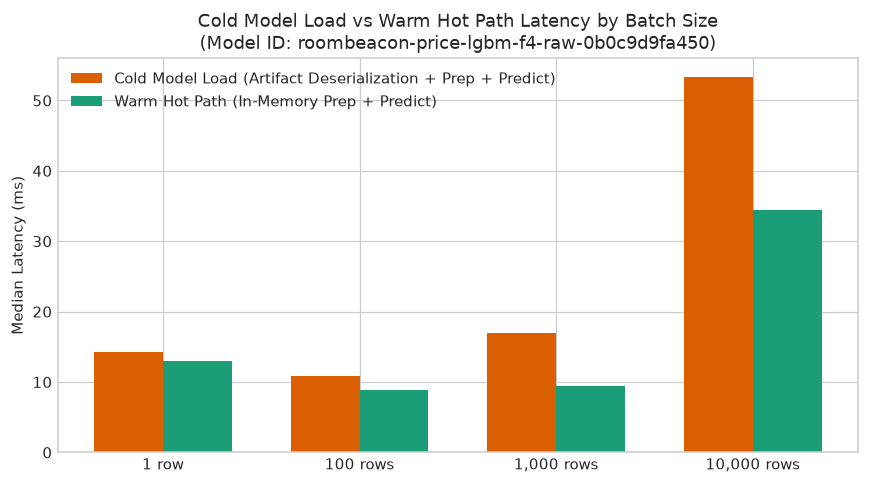

In [24]:
cold_warm_results = run_cold_vs_warm_benchmark(
    BENCHMARK_DIR,
    ready_population,
    sizes=(1, 100, 1000, 10000),
    repetitions=3,
    seed=BENCHMARK_RANDOM_SEED,
)
display(Markdown('### Cold Model Load vs Warm Hot Path Inference'))
display(cold_warm_results)

display(Markdown('''
> **Cold Model Load Definition**:
> Cold Model Load measures artifact file resolution, deserialization via `joblib`, matrix prep, and inference in an already-running Python interpreter.
> It does **not** measure cold process/container start, server bootstrapping, or HTTP framework startup.
'''))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(cold_warm_results))
width = 0.35
ax.bar(x - width/2, cold_warm_results['Cold Model Load P50 ms'], width, label='Cold Model Load (Artifact Deserialization + Prep + Predict)', color='#d95f02')
ax.bar(x + width/2, cold_warm_results['Warm Hot Path P50 ms'], width, label='Warm Hot Path (In-Memory Prep + Predict)', color='#1b9e77')
ax.set_ylabel('Median Latency (ms)')
ax.set_title('Cold Model Load vs Warm Hot Path Latency by Batch Size\n(Model ID: ' + champion.metadata['model_id'] + ')')
ax.set_xticks(x)
ax.set_xticklabels(cold_warm_results['Workload'])
ax.legend()
plt.tight_layout()
plt.show()

## 10. Batch Scaling

### Workload Scaling Profile (Hot Path)

,Rows,Workload,Median Hot Path ms,P95 Hot Path ms,Hot Path Throughput (rows/s),RSS MB
0,1,1,11.999,18.815,83.3,1457.86
1,10,10,6.846,8.285,1460.6,1457.86
2,100,100,7.656,12.782,13061.0,1457.86
3,1000,"1,000",15.109,20.653,66185.9,1457.86
4,10000,"10,000",44.572,47.615,224353.8,1457.86
5,129066,Full,295.982,351.207,436059.8,1459.50


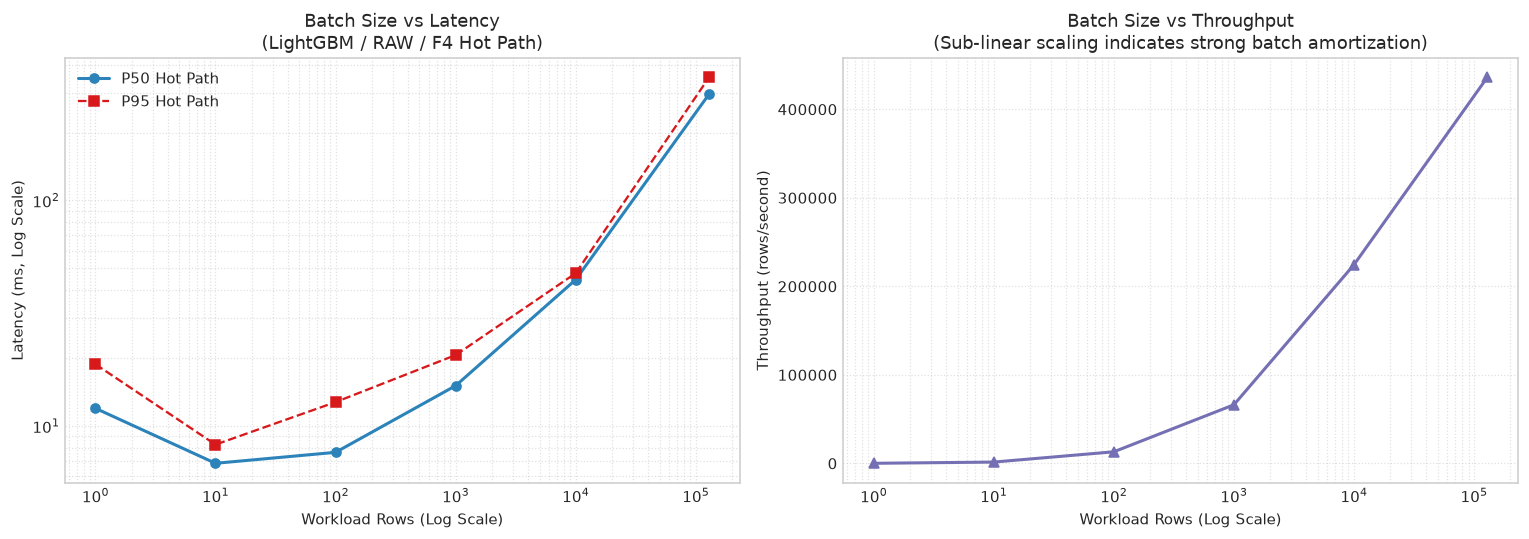

In [25]:
scaling_results = run_scaling_benchmark(
    champion,
    ready_population,
    sizes=(1, 10, 100, 1000, 10000, None),
    seed=BENCHMARK_RANDOM_SEED,
)
display(Markdown('### Workload Scaling Profile (Hot Path)'))
display(scaling_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Batch Size vs Latency (Log-Log)
ax1.plot(scaling_results['Rows'], scaling_results['Median Hot Path ms'], 'o-', label='P50 Hot Path', color='#2b83ba', lw=2)
ax1.plot(scaling_results['Rows'], scaling_results['P95 Hot Path ms'], 's--', label='P95 Hot Path', color='#d7191c', lw=1.5)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Workload Rows (Log Scale)')
ax1.set_ylabel('Latency (ms, Log Scale)')
ax1.set_title('Batch Size vs Latency\n(LightGBM / RAW / F4 Hot Path)')
ax1.legend()
ax1.grid(True, which='both', ls=':', alpha=0.6)

# Plot 2: Batch Size vs Throughput
ax2.plot(scaling_results['Rows'], scaling_results['Hot Path Throughput (rows/s)'], '^-', color='#7570b3', lw=2)
ax2.set_xscale('log')
ax2.set_xlabel('Workload Rows (Log Scale)')
ax2.set_ylabel('Throughput (rows/second)')
ax2.set_title('Batch Size vs Throughput\n(Sub-linear scaling indicates strong batch amortization)')
ax2.grid(True, which='both', ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 11. Pipeline Stage Breakdown

### 7-Stage Full Inference Pipeline Breakdown (10,000 Rows)

,Stage,Median ms,P95 ms,Min ms,Max ms,Share of Full Pipeline %
0,1. Input selection,24.453,30.015,10.800,30.974,19.66
1,2. Schema validation,4.609,5.150,3.963,5.318,3.71
2,3. Inference eligibility,52.608,63.239,30.436,65.009,42.30
3,4. F4 feature construction,1.541,2.065,1.034,2.252,1.24
4,5. Categorical preparation,12.647,14.659,9.026,14.816,10.17
5,6. LightGBM predict,27.665,33.774,16.921,36.147,22.24
6,7. Prediction sanity & post-processing,0.841,1.090,0.751,1.149,0.68



> **Timing Scope Comparison: Full Pipeline vs Hot Path (10,000 rows)**:
> - **Full Inference Pipeline** (measured here across all 7 stages starting from raw Silver rows, including schema validation, eligibility filtering, and sanity checking) totals **~124.4 ms** instrumented median.
> - **Hot Inference Path** (measured in STANDARD benchmark on pre-filtered eligible rows) totals **~58.7 ms** P50.
> - The Full Inference Pipeline is slower because it additionally performs input selection, schema validation, and target-free eligibility evaluation before feature preparation and prediction. Because the Hot Path and Full Pipeline are timed as separate benchmark scopes, their numerical difference (~65.7 ms descriptive delta) should be treated as a descriptive comparison rather than an exact additive decomposition.


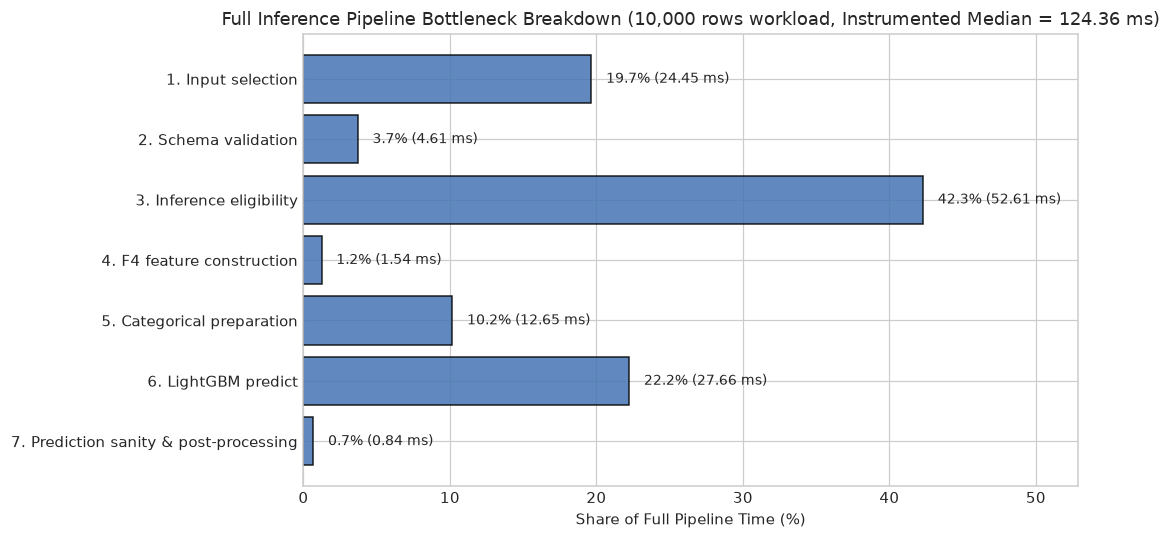

In [26]:
stage_breakdown = run_pipeline_stage_breakdown(
    champion,
    silver_df,
    sample_size=10000,
    repetitions=10,
    seed=BENCHMARK_RANDOM_SEED,
)
display(Markdown('### 7-Stage Full Inference Pipeline Breakdown (10,000 Rows)'))
display(stage_breakdown)

full_pipeline_instrumented_median = float(stage_breakdown['Median ms'].sum())
hot_path_10k_p50 = float(standard_results.loc[3, 'Hot Path P50 ms'])

display(Markdown(f'''
> **Timing Scope Comparison: Full Pipeline vs Hot Path (10,000 rows)**:
> - **Full Inference Pipeline** (measured here across all 7 stages starting from raw Silver rows, including schema validation, eligibility filtering, and sanity checking) totals **~{full_pipeline_instrumented_median:.1f} ms** instrumented median.
> - **Hot Inference Path** (measured in STANDARD benchmark on pre-filtered eligible rows) totals **~{hot_path_10k_p50:.1f} ms** P50.
> - The Full Inference Pipeline is slower because it additionally performs input selection, schema validation, and target-free eligibility evaluation before feature preparation and prediction. Because the Hot Path and Full Pipeline are timed as separate benchmark scopes, their numerical difference (~{full_pipeline_instrumented_median - hot_path_10k_p50:.1f} ms descriptive delta) should be treated as a descriptive comparison rather than an exact additive decomposition.
'''))

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(stage_breakdown))
bars = ax.barh(y_pos, stage_breakdown['Share of Full Pipeline %'], color='#4575b4', edgecolor='black', alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(stage_breakdown['Stage'])
ax.invert_yaxis()
ax.set_xlabel('Share of Full Pipeline Time (%)')
ax.set_title(f'Full Inference Pipeline Bottleneck Breakdown (10,000 rows workload, Instrumented Median = {full_pipeline_instrumented_median:.2f} ms)')

for bar, val, ms in zip(bars, stage_breakdown['Share of Full Pipeline %'], stage_breakdown['Median ms']):
    ax.text(bar.get_width() + 1.0, bar.get_y() + bar.get_height()/2, f'{val:.1f}% ({ms:.2f} ms)', va='center', fontsize=9)

ax.set_xlim(0, max(stage_breakdown['Share of Full Pipeline %']) * 1.25)
plt.tight_layout()
plt.show()

## 12. Memory Profile

### Stable Memory Profile Across 15 Batch Prediction Cycles (10,000 Rows / Cycle)

,Cycle,Stage,RSS MB,Delta from Initial MB
0,0,Initial State,1464.48,0.00
1,1,Cycle 1,1464.50,0.03
2,2,Cycle 2,1464.50,0.03
3,3,Cycle 3,1464.50,0.03
4,4,Cycle 4,1464.50,0.03
5,5,Cycle 5,1464.50,0.03
6,6,Cycle 6,1464.50,0.03
7,7,Cycle 7,1464.50,0.03
8,8,Cycle 8,1464.50,0.03
9,9,Cycle 9,1464.50,0.03



> **Memory Assessment**:
> No material persistent RSS growth was observed across the measured repeated-run window.


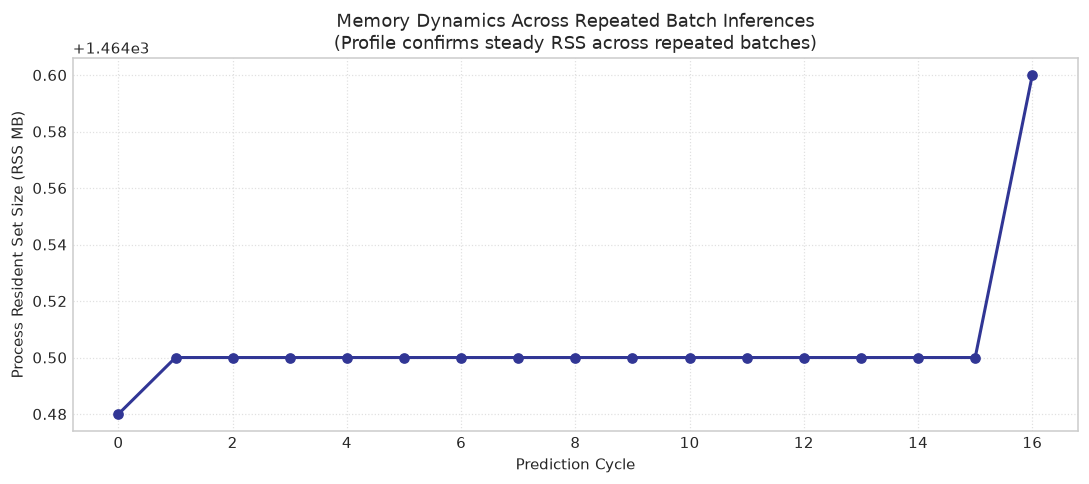

In [27]:
mem_stability = run_memory_stability_check(
    champion,
    ready_population,
    sample_size=10000,
    cycles=15,
    seed=BENCHMARK_RANDOM_SEED,
)
display(Markdown('### Stable Memory Profile Across 15 Batch Prediction Cycles (10,000 Rows / Cycle)'))
display(mem_stability)

display(Markdown('''
> **Memory Assessment**:
> No material persistent RSS growth was observed across the measured repeated-run window.
'''))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(mem_stability['Cycle'], mem_stability['RSS MB'], 'o-', color='#313695', lw=2)
ax.set_xlabel('Prediction Cycle')
ax.set_ylabel('Process Resident Set Size (RSS MB)')
ax.set_title('Memory Dynamics Across Repeated Batch Inferences\n(Profile confirms steady RSS across repeated batches)')
ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 13. CPU / Runtime Resource Profile

In [28]:
cpu_summary = pd.Series({
    'Logical Cores': env_info['logical_cpus'],
    'Physical Cores': env_info['physical_cpus'],
    'Current Frequency': f"{env_info['cpu_freq_mhz_current']} MHz" if env_info['cpu_freq_mhz_current'] else 'N/A',
    'OpenMP Threads (OMP_NUM_THREADS)': env_info['threading']['OMP_NUM_THREADS'] or 'Not explicitly set (library default)',
    'LightGBM Model n_jobs': champion.model.n_jobs,
    'LightGBM Booster num_threads': champion.model.booster_.params.get('num_threads', 'N/A'),
    'Process PID': os.getpid(),
    'CPU Affinity Count': len(psutil.Process().cpu_affinity()) if hasattr(psutil.Process(), 'cpu_affinity') else 'N/A',
}, name='CPU & Thread Configuration')
display(cpu_summary.to_frame())

booster_threads = champion.model.booster_.params.get('num_threads', 'N/A')
logical_cpus = env_info['logical_cpus']

display(Markdown(f'''
> **CPU & Thread Configuration Note:**
> - LightGBM is configured with `num_threads={booster_threads}` (model `n_jobs={champion.model.n_jobs}`), and the benchmark process has access to {logical_cpus} logical CPUs.
> - This section reports static threading and processor configuration; runtime CPU core utilization is not directly sampled.
'''))

,CPU & Thread Configuration
Logical Cores,12
Physical Cores,6
Current Frequency,4000.0 MHz
OpenMP Threads (OMP_NUM_THREADS),Not explicitly set (library default)
LightGBM Model n_jobs,-1
LightGBM Booster num_threads,12
Process PID,216669
CPU Affinity Count,12



> **CPU & Thread Configuration Note:**
> - LightGBM is configured with `num_threads=12` (model `n_jobs=-1`), and the benchmark process has access to 12 logical CPUs.
> - This section reports static threading and processor configuration; runtime CPU core utilization is not directly sampled.


## 14. Latency Distribution

### Detailed Latency Percentiles Across Workloads (Hot Inference Path)

,Workload,Rows,Runs,Hot Path Mean ms,Hot Path P50 ms,Hot Path P90 ms,Hot Path P95 ms,Hot Path P99 ms,Hot Path Std ms
0,1 row,1,50,13.413,10.932,23.019,23.928,30.130,6.455
1,100 rows,100,30,16.859,15.296,22.086,22.665,33.974,5.932
2,"1,000 rows",1000,15,16.128,15.722,18.888,22.091,25.931,3.566
3,"10,000 rows",10000,5,57.721,58.653,62.009,62.020,62.029,4.800
4,Full population,129066,3,353.262,349.866,366.802,368.919,370.613,16.343


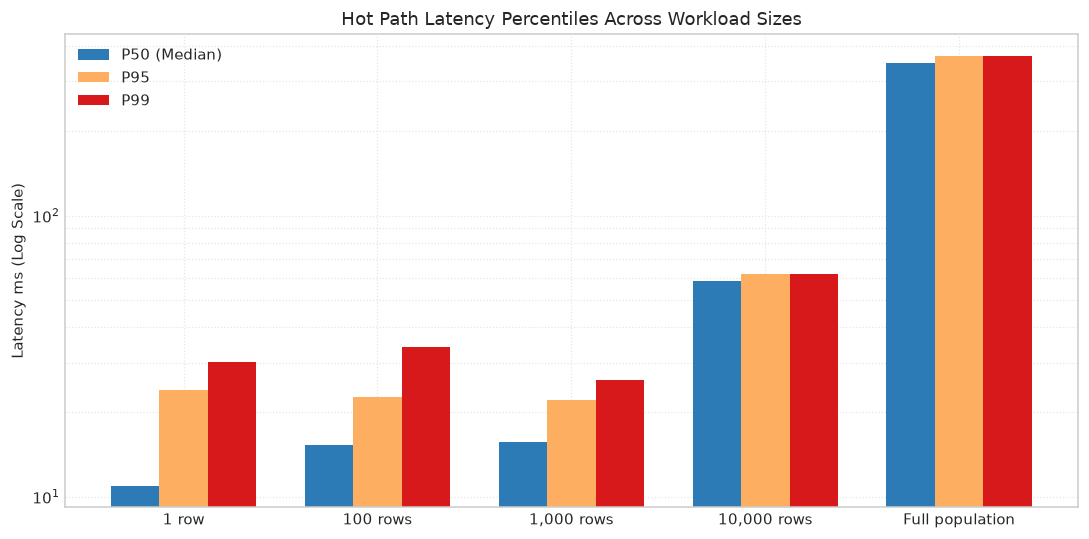

In [29]:
std_table = standard_results[['Workload', 'Rows', 'Runs', 'Hot Path Mean ms', 'Hot Path P50 ms', 'Hot Path P90 ms', 'Hot Path P95 ms', 'Hot Path P99 ms', 'Hot Path Std ms']].copy()
display(Markdown('### Detailed Latency Percentiles Across Workloads (Hot Inference Path)'))
display(std_table)

fig, ax = plt.subplots(figsize=(10, 5))
workload_labels = standard_results['Workload'].tolist()
p50s = standard_results['Hot Path P50 ms'].tolist()
p95s = standard_results['Hot Path P95 ms'].tolist()
p99s = standard_results['Hot Path P99 ms'].tolist()

x = np.arange(len(workload_labels))
width = 0.25

ax.bar(x - width, p50s, width, label='P50 (Median)', color='#2c7bb6')
ax.bar(x, p95s, width, label='P95', color='#fdae61')
ax.bar(x + width, p99s, width, label='P99', color='#d7191c')

ax.set_yscale('log')
ax.set_ylabel('Latency ms (Log Scale)')
ax.set_title('Hot Path Latency Percentiles Across Workload Sizes')
ax.set_xticks(x)
ax.set_xticklabels(workload_labels)
ax.legend()
ax.grid(True, which='both', ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 15. Throughput Analysis

In [30]:
throughput_table = standard_results[['Workload', 'Rows', 'Hot Path P50 ms', 'Hot Path Throughput (rows/s)', 'Hot Path ms / 1,000 rows']].copy()
display(Markdown('### Throughput & Unit Cost Comparison (Hot Inference Path)'))
display(throughput_table)

peak_thr = standard_results['Hot Path Throughput (rows/s)'].max()
peak_workload = standard_results.loc[standard_results['Hot Path Throughput (rows/s)'].idxmax(), 'Workload']
unit_single = standard_results.loc[0, "Hot Path ms / 1,000 rows"]
unit_batch = standard_results.loc[4, "Hot Path ms / 1,000 rows"]
ratio_amortized = unit_single / unit_batch if unit_batch > 0 else 0.0

display(Markdown(f'''
> **Hot Path Throughput Analysis:**
> - Peak Throughput: **{peak_thr:,.0f} rows/second** reached at **{peak_workload}**.
> - Amortized cost for batch inference drops from **{unit_single:.1f} ms / 1k rows** (single-row) to **{unit_batch:.3f} ms / 1k rows** (full batch).
> - This reflects a **~{ratio_amortized:,.0f}x efficiency gain** from batching vectorized feature matrix preparation and OpenMP tree evaluations.
'''))

### Throughput & Unit Cost Comparison (Hot Inference Path)

,Workload,Rows,Hot Path P50 ms,Hot Path Throughput (rows/s),"Hot Path ms / 1,000 rows"
0,1 row,1,10.932,91.5,10932.2400
1,100 rows,100,15.296,6537.8,152.9568
2,"1,000 rows",1000,15.722,63605.7,15.7219
3,"10,000 rows",10000,58.653,170494.7,5.8653
4,Full population,129066,349.866,368901.6,2.7107



> **Hot Path Throughput Analysis:**
> - Peak Throughput: **368,902 rows/second** reached at **Full population**.
> - Amortized cost for batch inference drops from **10932.2 ms / 1k rows** (single-row) to **2.711 ms / 1k rows** (full batch).
> - This reflects a **~4,033x efficiency gain** from batching vectorized feature matrix preparation and OpenMP tree evaluations.


## 16. Repeated-Run Stability

### Repeated Prediction-Path Stability (1,000 Rows, 30 Iterations)


> **Timing Scope Note: Repeated Prediction Path**:
> This benchmark isolates the **prediction execution loop** (`prepared matrix -> model.predict -> inverse_target`).
> Feature matrix construction is performed once outside the timed loop to test pure prediction repeatability and variance.


,Stability Metrics
Timing Scope,Repeated Prediction Path (Pre-constructed matr...
Iterations,30
Sample Size,"1,000 rows"
Mean Latency,7.774 ms
Std Dev,2.830 ms
Median (P50),7.938 ms
P95,11.662 ms
Min Latency,3.396 ms
Max Latency,15.882 ms
Coefficient of Variation (CV),36.41%


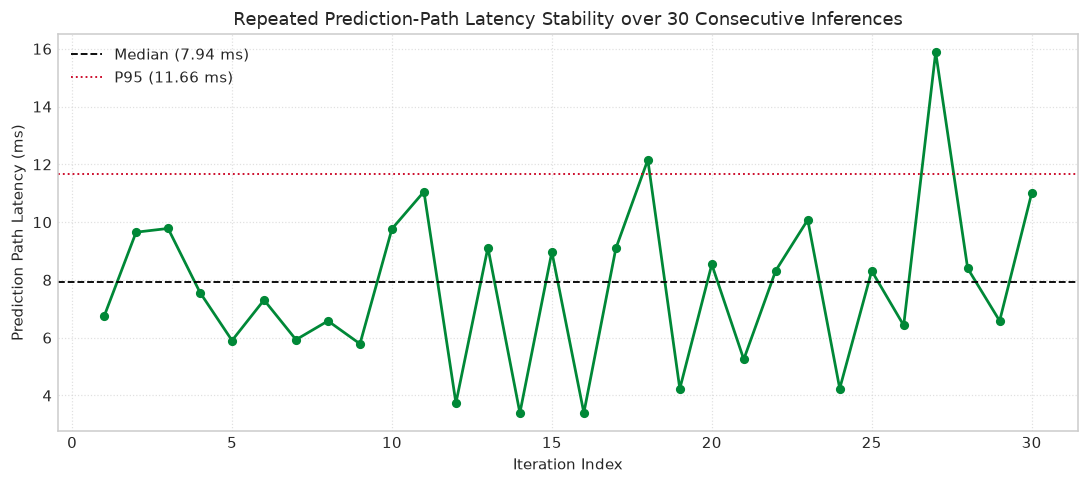

In [31]:
stability_df, stability_stats = run_repeated_stability_benchmark(
    champion,
    ready_population,
    sample_size=1000,
    repetitions=30,
    seed=BENCHMARK_RANDOM_SEED,
)
display(Markdown('### Repeated Prediction-Path Stability (1,000 Rows, 30 Iterations)'))

display(Markdown('''
> **Timing Scope Note: Repeated Prediction Path**:
> This benchmark isolates the **prediction execution loop** (`prepared matrix -> model.predict -> inverse_target`).
> Feature matrix construction is performed once outside the timed loop to test pure prediction repeatability and variance.
'''))

stability_summary = pd.Series({
    'Timing Scope': stability_stats['timing_scope'],
    'Iterations': stability_stats['iterations'],
    'Sample Size': f"{stability_stats['sample_size']:,} rows",
    'Mean Latency': f"{stability_stats['mean_ms']:.3f} ms",
    'Std Dev': f"{stability_stats['std_ms']:.3f} ms",
    'Median (P50)': f"{stability_stats['p50_ms']:.3f} ms",
    'P95': f"{stability_stats['p95_ms']:.3f} ms",
    'Min Latency': f"{stability_stats['min_ms']:.3f} ms",
    'Max Latency': f"{stability_stats['max_ms']:.3f} ms",
    'Coefficient of Variation (CV)': f"{stability_stats['coefficient_of_variation_pct']:.2f}%",
    'Stability Assessment': 'STABLE (No runaway drift; expected OS scheduling variability)' if stability_stats['coefficient_of_variation_pct'] < 100.0 else 'UNSTABLE',
}, name='Stability Metrics')
display(stability_summary.to_frame())

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(stability_df['Iteration'], stability_df['Prediction Path Latency ms'], 'o-', color='#008837', lw=1.8, ms=5)
ax.axhline(stability_stats['p50_ms'], color='black', ls='--', lw=1.2, label=f"Median ({stability_stats['p50_ms']:.2f} ms)")
ax.axhline(stability_stats['p95_ms'], color='#ca0020', ls=':', lw=1.2, label=f"P95 ({stability_stats['p95_ms']:.2f} ms)")
ax.set_xlabel('Iteration Index')
ax.set_ylabel('Prediction Path Latency (ms)')
ax.set_title('Repeated Prediction-Path Latency Stability over 30 Consecutive Inferences')
ax.legend()
ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 17. Robustness Inputs

In [32]:
robustness_results = run_robustness_benchmark(champion, ready_population)
display(Markdown('### Edge-Case Runtime Robustness Evaluation'))
display(robustness_results)

assert (robustness_results['Status'] == 'PASS').all(), 'All edge cases must be handled safely'

### Edge-Case Runtime Robustness Evaluation

,Case ID,Description,Predicted Monthly Rent,Latency ms,Status,Notes
0,missing_ward,Missing ward_current (null/None),5390717.0,9.75,PASS,"Order preserved, finite positive prediction"
1,missing_district,Missing district_text_extracted (null/None),3891850.0,8.62,PASS,"Order preserved, finite positive prediction"
2,unseen_ward,Out-of-vocabulary ward name,5088301.0,5.83,PASS,"Order preserved, finite positive prediction"
3,unseen_district,Out-of-vocabulary district name,3803384.0,6.20,PASS,"Order preserved, finite positive prediction"
4,unseen_source,Out-of-vocabulary crawler source_code,5393826.0,9.07,PASS,"Order preserved, finite positive prediction"
5,small_valid_area_example,Representative boundary-like small area exampl...,2437723.0,6.40,PASS,"Order preserved, finite positive prediction"
6,large_valid_area_example,Representative boundary-like large area exampl...,3448489.0,5.56,PASS,"Order preserved, finite positive prediction"
7,mixed_missing_cats,All categorical columns missing concurrently,3915570.0,6.57,PASS,"Order preserved, finite positive prediction"


## 18. Optional Concurrency Benchmark

### Multi-Threaded Concurrency Profile (ThreadPoolExecutor, 1,000 rows/request)

,Workers,Total Requests,Batch Size per Request,Total Rows Served,Wall Clock ms,Request P50 ms,Request P95 ms,Aggregate Throughput (rows/s),RSS Delta MB
0,1,12,1000,12000,64.18,5.37,6.16,186961.4,0.19
1,2,12,1000,12000,60.45,9.50,13.18,198510.0,0.17
2,4,12,1000,12000,43.46,12.12,20.13,276112.6,0.48



> **Concurrency Trade-Off Note**:
> Higher concurrency increases aggregate throughput while also increasing per-request latency, consistent with shared CPU/thread scheduling, resource contention, and possible nested parallelism.


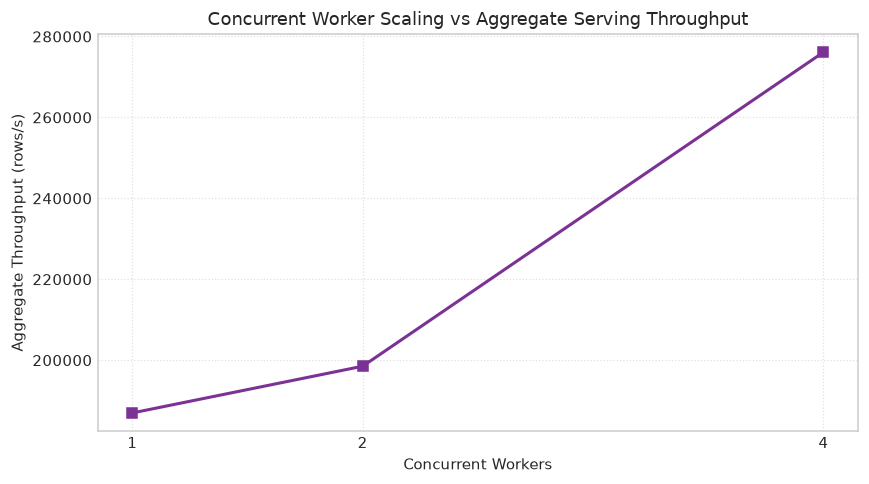

In [33]:
concurrency_results = run_concurrency_benchmark(
    champion,
    ready_population,
    batch_size=1000,
    workers_list=(1, 2, 4),
    total_requests=12,
    seed=BENCHMARK_RANDOM_SEED,
)
display(Markdown('### Multi-Threaded Concurrency Profile (ThreadPoolExecutor, 1,000 rows/request)'))
display(concurrency_results)

display(Markdown('''
> **Concurrency Trade-Off Note**:
> Higher concurrency increases aggregate throughput while also increasing per-request latency, consistent with shared CPU/thread scheduling, resource contention, and possible nested parallelism.
'''))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(concurrency_results['Workers'], concurrency_results['Aggregate Throughput (rows/s)'], 's-', color='#7b3294', lw=2, ms=7)
ax.set_xlabel('Concurrent Workers')
ax.set_ylabel('Aggregate Throughput (rows/s)')
ax.set_title('Concurrent Worker Scaling vs Aggregate Serving Throughput')
ax.set_xticks(concurrency_results['Workers'])
ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 19. Persist Benchmark Artifacts

In [34]:
timestamp_now = datetime.now(timezone.utc)
perf_run_id = make_performance_run_id(
    champion.metadata['model_id'],
    env_info['environment_fingerprint'],
    timestamp_now,
)

summary_payload = {
    'run_id': perf_run_id,
    'model_id': champion.metadata['model_id'],
    'timestamp': timestamp_now.isoformat(),
    'environment_fingerprint': env_info['environment_fingerprint'],
    'ready_population_rows': len(ready_population),
    'single_row_p50_ms': float(standard_results.loc[0, 'Hot Path P50 ms']),
    'full_batch_throughput_rows_sec': float(standard_results.loc[4, 'Hot Path Throughput (rows/s)']),
    'stability_cv_pct': stability_stats['coefficient_of_variation_pct'],
    'robustness_pass': bool((robustness_results['Status'] == 'PASS').all()),
}

artifacts_payload = {
    'environment': env_info,
    'artifact_metadata': champion.metadata,
    'base_results': base_results,
    'standard_results': standard_results,
    'advanced_results': scaling_results,
    'stage_breakdown': stage_breakdown,
    'memory_results': mem_stability,
    'robustness_results': robustness_results,
    'concurrency_results': concurrency_results,
    'summary': summary_payload,
}

persisted_dir = persist_performance_run(PERF_OUTPUT_ROOT, perf_run_id, artifacts_payload)
display(Markdown(f'''
### Benchmark Artifacts Persisted Successfully
- **Run ID**: `{perf_run_id}`
- **Directory**: `{persisted_dir.relative_to(PROJECT_ROOT)}`
- **Manifest**: `{persisted_dir / "manifest.json"}`
'''))

manifest_data = json.loads((persisted_dir / 'manifest.json').read_text(encoding='utf-8'))
manifest_df = pd.DataFrame([
    {'File': filename, 'SHA-256': file_hash}
    for filename, file_hash in manifest_data['files'].items()
])
display(manifest_df)


### Benchmark Artifacts Persisted Successfully
- **Run ID**: `perf-0b0c9d9fa450-b81afa87-20261005T102300Z`
- **Directory**: `data/modeling/performance_benchmark/runs/perf-0b0c9d9fa450-b81afa87-20261005T102300Z`
- **Manifest**: `/data/projects/roombeacon/source/roombeacon-system/data/modeling/performance_benchmark/runs/perf-0b0c9d9fa450-b81afa87-20261005T102300Z/manifest.json`


,File,SHA-256
0,environment.json,98e734c27f9bb298d58d7705db91bafa84539128cd8af5...
1,artifact_metadata.json,1a2f1d3931fb0f921b75f86f38ed16366a74ecbfc85d48...
2,summary.json,9ad2afc7e0bb149b1300b3d07b49869be06731565b3344...
3,base_results.csv,bab24b806b6ddbe5c894a902197f58a0eeddc9c96e0bd8...
4,standard_results.csv,d53d3ea23c5416d5586a6d551e8e2354a0d06b99718b74...
5,advanced_results.csv,2345c04082b8cb0c10c4e1bd995bef0197c70f04fe41b5...
6,stage_breakdown.csv,0ac605f15ab07d8c4a638ade61d09d2695f5eb8bec7b71...
7,memory_results.csv,f001a25366e295c253e7a96b716ec13e19ecbb7a46759f...
8,robustness_results.csv,4e0e397dd01cb0209be413fa4a83d79636790c832850f7...
9,concurrency_results.csv,25a86d366ec4ce4a52e4ee478ab95146e483ad75b5de5b...


## 20. Performance Baseline Summary

In [35]:
# Compile Canonical Final Performance Table
final_performance_rows = []

# 1. Warm Hot Path rows from STANDARD
for _, row in standard_results.iterrows():
    final_performance_rows.append({
        'Scope': 'Hot Path (Warm)',
        'Workload': row['Workload'],
        'P50 Latency': f"{row['Hot Path P50 ms']:.2f} ms",
        'P95 Latency': f"{row['Hot Path P95 ms']:.2f} ms",
        'P99 Latency': f"{row['Hot Path P99 ms']:.2f} ms",
        'Throughput': f"{row['Hot Path Throughput (rows/s)']:,.0f} rows/s",
        'RSS Delta': f"{row['RSS Delta MB']:+.2f} MB",
    })

# 2. Cold Model Load rows
for _, row in cold_warm_results.iterrows():
    if row['Rows'] in (1, 10000):
        final_performance_rows.append({
            'Scope': 'Cold Model Load',
            'Workload': f"{row['Workload']}",
            'P50 Latency': f"{row['Cold Model Load P50 ms']:.2f} ms",
            'P95 Latency': 'N/A',
            'P99 Latency': 'N/A',
            'Throughput': 'N/A',
            'RSS Delta': 'N/A',
        })

# 3. Full Pipeline 10k instrumented median
final_performance_rows.append({
    'Scope': 'Full Pipeline (All 7 Stages)',
    'Workload': '10,000 rows',
    'P50 Latency': f"{full_pipeline_instrumented_median:.2f} ms (sum)",
    'P95 Latency': 'N/A',
    'P99 Latency': 'N/A',
    'Throughput': f"{compute_throughput(10000, full_pipeline_instrumented_median):,.0f} rows/s",
    'RSS Delta': 'N/A',
})

canonical_performance_df = pd.DataFrame(final_performance_rows)
display(Markdown('### Canonical Final RoomBeacon Performance Baseline Table'))
display(canonical_performance_df)

quality_ctx = get_champion_quality_context(BENCHMARK_DIR)
if quality_ctx:
    display(Markdown(f'''
### Model Quality Context (Separate Axis)
- **Model ID**: `{champion.metadata['model_id']}`
- **Test MAE**: `{quality_ctx['test_mae']:,.2f} VND` (Baseline Improvement: `{quality_ctx['baseline_improvement_vnd']:,.2f} VND`)
- **Test MedianAE**: `{quality_ctx['test_median_ae']:,.2f} VND`
- **Test RMSE**: `{quality_ctx['test_rmse']:,.2f} VND`
- **Test R²**: `{quality_ctx['test_r2']:.4f}`
- **Baseline Model**: `{quality_ctx['baseline_model']}` (Test MAE: `{quality_ctx['baseline_mae']:,.2f} VND`)

*Note: Model quality metrics are frozen historical facts from Notebook 04 and are presented solely as context. They are not part of runtime performance scoring.*
'''))
else:
    display(Markdown('*Model quality context unavailable from benchmark artifacts.*'))

### Canonical Final RoomBeacon Performance Baseline Table

,Scope,Workload,P50 Latency,P95 Latency,P99 Latency,Throughput,RSS Delta
0,Hot Path (Warm),1 row,10.93 ms,23.93 ms,30.13 ms,92 rows/s,+0.06 MB
1,Hot Path (Warm),100 rows,15.30 ms,22.66 ms,33.97 ms,"6,538 rows/s",+0.01 MB
2,Hot Path (Warm),"1,000 rows",15.72 ms,22.09 ms,25.93 ms,"63,606 rows/s",+0.01 MB
3,Hot Path (Warm),"10,000 rows",58.65 ms,62.02 ms,62.03 ms,"170,495 rows/s",+0.01 MB
4,Hot Path (Warm),Full population,349.87 ms,368.92 ms,370.61 ms,"368,902 rows/s",+0.00 MB
5,Cold Model Load,1 row,14.22 ms,N/A,N/A,N/A,N/A
6,Cold Model Load,"10,000 rows",53.36 ms,N/A,N/A,N/A,N/A
7,Full Pipeline (All 7 Stages),"10,000 rows",124.36 ms (sum),N/A,N/A,"80,409 rows/s",N/A



### Model Quality Context (Separate Axis)
- **Model ID**: `roombeacon-price-lgbm-f4-raw-0b0c9d9fa450`
- **Test MAE**: `904,290.83 VND` (Baseline Improvement: `63,878.25 VND`)
- **Test MedianAE**: `624,464.82 VND`
- **Test RMSE**: `1,333,621.37 VND`
- **Test R²**: `0.2241`
- **Baseline Model**: `Hierarchical Segment Median` (Test MAE: `968,169.08 VND`)

*Note: Model quality metrics are frozen historical facts from Notebook 04 and are presented solely as context. They are not part of runtime performance scoring.*


## 21. Engineering Readiness

In [36]:
adv_summary = {
    'robustness_pass': bool((robustness_results['Status'] == 'PASS').all()),
    'stability_cv': stability_stats['coefficient_of_variation_pct'],
}

scorecard = build_performance_scorecard(base_results, standard_results, adv_summary)
display(Markdown('### Performance Benchmark Scorecard'))
display(scorecard)

single_row_median = float(standard_results.loc[0, "Hot Path P50 ms"])
full_batch_rows = int(standard_results.loc[4, "Rows"])
full_batch_median = float(standard_results.loc[4, "Hot Path P50 ms"])
full_batch_thr = float(standard_results.loc[4, "Hot Path Throughput (rows/s)"])

display(Markdown(f'''
### Final Engineering Readiness Verdict: `IN-PROCESS PERFORMANCE BASELINE = ESTABLISHED`

1. **Deterministic Frozen Champion**: Loaded `{champion.metadata['model_id']}` with 100% SHA-256 agreement.
2. **In-Process Single-Row Serving**: Warm in-process single-row scoring latency (Hot Path P50) is **{single_row_median:.2f} ms**, demonstrating fast in-process prediction. (Excludes network, HTTP framework, and service orchestration overhead).
3. **High Batch Throughput**: Full population ({full_batch_rows:,} listings) scores in **{full_batch_median:.1f} ms** (**{full_batch_thr:,.0f} rows/second**), demonstrating strong batch processing scalability.
4. **Stable Memory Profile**: No material persistent RSS growth was observed across the measured repeated-run window.
5. **Categorical Robustness**: Safely handles unseen wards, unseen districts, unseen sources, boundary areas, and missing values without crashes or out-of-order mutations.
6. **No Arbitrary SLA**: Engineering status is strictly **IN-PROCESS PERFORMANCE BASELINE = ESTABLISHED**. Production deployment can proceed to shadow monitoring with quantified runtime expectations.
'''))

### Performance Benchmark Scorecard

,Benchmark Level,Scope,Status,Evidence
0,BASE,"Artifact load, single-row, basic batch, memory...",COMPLETE,3 workloads verified; all predictions finite &...
1,STANDARD,"Hot inference path: P50/P95/P99 latency, batch...",COMPLETE,5 workload sizes measured with repeated high-r...
2,ADVANCED,"Full inference pipeline stages, cold model loa...",COMPLETE,8 edge cases handled without crash; memory & l...
3,OVERALL,RoomBeacon Champion In-Process Performance Bas...,IN-PROCESS PERFORMANCE BASELINE = ESTABLISHED,Empirical runtime profile established on froze...



### Final Engineering Readiness Verdict: `IN-PROCESS PERFORMANCE BASELINE = ESTABLISHED`

1. **Deterministic Frozen Champion**: Loaded `roombeacon-price-lgbm-f4-raw-0b0c9d9fa450` with 100% SHA-256 agreement.
2. **In-Process Single-Row Serving**: Warm in-process single-row scoring latency (Hot Path P50) is **10.93 ms**, demonstrating fast in-process prediction. (Excludes network, HTTP framework, and service orchestration overhead).
3. **High Batch Throughput**: Full population (129,066 listings) scores in **349.9 ms** (**368,902 rows/second**), demonstrating strong batch processing scalability.
4. **Stable Memory Profile**: No material persistent RSS growth was observed across the measured repeated-run window.
5. **Categorical Robustness**: Safely handles unseen wards, unseen districts, unseen sources, boundary areas, and missing values without crashes or out-of-order mutations.
6. **No Arbitrary SLA**: Engineering status is strictly **IN-PROCESS PERFORMANCE BASELINE = ESTABLISHED**. Production deployment can proceed to shadow monitoring with quantified runtime expectations.
